In [1]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import norm
import pandas as pd
from scipy import stats
from itertools import product
from scipy import linalg
from functools import partial

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork, BernoulliNetwork
from src.metrics import (
    TrueRejection,
    FalseRejection,
    Rejection,
    RelativeFrobeniusNorm,
    rv_coefficient_adjusted,
    rv_coefficient,
    ComputeAll,
)
from src.methods import (
    RVPermutationTest,
    FitIndependent,
    LLKRatioTest,
    DiffusionCorrelation,
    CanonicalCorrelationTest
)
from src.solvers import MLE_logistic, ASE, MLE_gaussian
from src.simulation_functions import run_simulation
from src.analyse_functions import aggregate_results
from src.plot_functions import plot_grid, plot_with_bands
import scipy.stats as stats
from src.methods import QAP
from src.plot_functions import visualise_latent

In [2]:
def check_normality(data, label):
    print(f"--- Normality Report for: {label} ---")

    # --- Descriptive Statistics ---
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)
    print(f"Skewness: {skew:.4f} (Ideal: 0)")
    print(f"Excess Kurtosis: {kurt:.4f} (Ideal: 0)")

    # --- Shapiro-Wilk Test ---
    # Good for small to medium samples (n < 5000)
    shapiro_stat, shapiro_p = stats.shapiro(data)
    print(
        f"Shapiro-Wilk Test: p={shapiro_p:.4f} ({'Normal' if shapiro_p > 0.05 else 'Not Normal'})"
    )

    # --- D'Agostino's K^2 Test ---
    k2_stat, k2_p = stats.normaltest(data)
    print(
        f"D'Agostino's K^2: p={k2_p:.4f} ({'Normal' if k2_p > 0.05 else 'Not Normal'})"
    )

    # --- Anderson-Darling Test ---
    result = stats.anderson(data)
    print(f"Anderson-Darling Stat: {result.statistic:.4f}")
    # Compare against critical value at 5% (index 2)
    is_normal = result.statistic < result.critical_values[2]
    print(f"Anderson-Darling (5%): {'Normal' if is_normal else 'Not Normal'}\n")

In [3]:
# out = []
# for i in range(10):
#     m = BernoulliNetwork(n=500, k=2, sigma=0)
#     data = m.generate()
#     A = data['A']
#     B = data['B']
#     X = data['X']
#     Z = data['Z']

#     rng = np.random.default_rng()

#     Xhat = MLE_logistic(A, k=2, rng=rng)
#     Zhat = MLE_logistic(B, k=2, rng=rng)

#     Xhat = Xhat[0][0]
#     Zhat = Zhat[0][0]

#     # check_normality(Xhat[:, 0], "Xhat")
#     # check_normality(X[:, 0], "X")

#     # fig, ax = plt.subplots(1, 1, figsize=(7, 5))
#     # ax.hist(Xhat[:, 0], alpha=0.75)
#     # ax.hist(X[:, 0], alpha=0.75)
#     # plt.legend(["$X_{hat}$", "$X$"])
#     # plt.show()

#     out.append(norm(Xhat))

# sum(out) / len(out)

--- Normality Report for: Xhat ---
Skewness: 0.2103 (Ideal: 0)
Excess Kurtosis: -0.8306 (Ideal: 0)
Shapiro-Wilk Test: p=0.0028 (Not Normal)
D'Agostino's K^2: p=0.0002 (Not Normal)
Anderson-Darling Stat: 1.0287
Anderson-Darling (5%): Not Normal

--- Normality Report for: X ---
Skewness: 0.1039 (Ideal: 0)
Excess Kurtosis: 0.2706 (Ideal: 0)
Shapiro-Wilk Test: p=0.5822 (Normal)
D'Agostino's K^2: p=0.5160 (Normal)
Anderson-Darling Stat: 0.3221
Anderson-Darling (5%): Normal



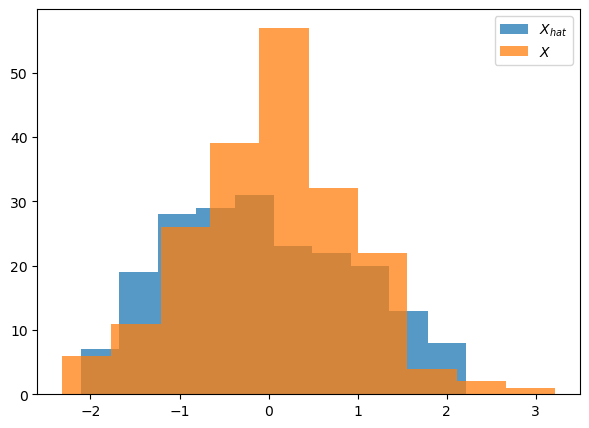

In [9]:
m = BernoulliNetwork(n=200, k=5, rho=0.5, copula_model='gaussian', marginals='gaussian')
data = m.generate()
A = data['A']
B = data['B']
X = data['X']
Z = data['Z']

rng = np.random.default_rng(42)

X_model = FitIndependent(rng=rng, k=2, solver=MLE_logistic)
X_model.fit(data)
Z_model = FitIndependent(rng=rng, k=2, solver=MLE_logistic)
Z_model.fit(data)

Xhat = X_model.get_estimated()['estimated_latent'][0]
Zhat = Z_model.get_estimated()['estimated_latent'][0]

check_normality(Xhat[:, 0], "Xhat")
check_normality(X[:, 0], "X")

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.hist(Xhat[:, 0], alpha=0.75)
ax.hist(X[:, 0], alpha=0.75)
plt.legend(["$X_{hat}$", "$X$"])
plt.show()

--- Normality Report for: Xhat ---
Skewness: 0.0330 (Ideal: 0)
Excess Kurtosis: -0.0665 (Ideal: 0)
Shapiro-Wilk Test: p=0.7925 (Normal)
D'Agostino's K^2: p=0.9755 (Normal)
Anderson-Darling Stat: 0.2256
Anderson-Darling (5%): Normal

--- Normality Report for: X ---
Skewness: 0.0356 (Ideal: 0)
Excess Kurtosis: -1.3697 (Ideal: 0)
Shapiro-Wilk Test: p=0.0000 (Not Normal)
D'Agostino's K^2: p=0.0000 (Not Normal)
Anderson-Darling Stat: 2.0932
Anderson-Darling (5%): Not Normal



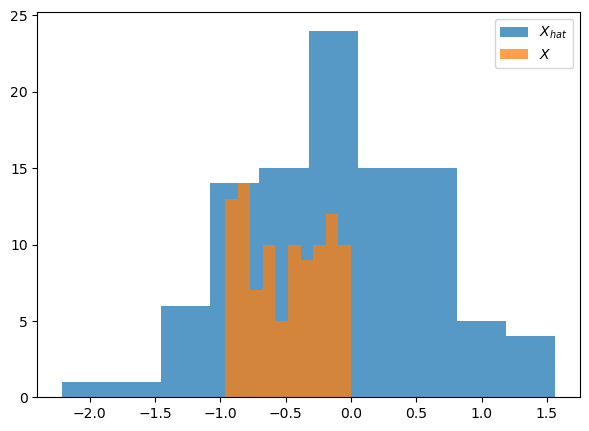

In [21]:
m = BernoulliNetwork(n=100, k=5, rho=0.5, copula_model='gaussian', marginals='uniform -1 1')
data = m.generate()
A = data['A']
B = data['B']
X = data['X']
Z = data['Z']

rng = np.random.default_rng(42)

X_model = FitIndependent(rng=rng, k=2, solver=MLE_logistic)
X_model.fit(data)
Z_model = FitIndependent(rng=rng, k=2, solver=MLE_logistic)
Z_model.fit(data)

Xhat = X_model.get_estimated()['estimated_latent'][0]
Zhat = Z_model.get_estimated()['estimated_latent'][0]

check_normality(Xhat[:, 0], "Xhat")
check_normality(X[:, 0], "X")

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.hist(Xhat[:, 0], alpha=0.75)
ax.hist(X[:, 0], alpha=0.75)
plt.legend(["$X_{hat}$", "$X$"])
plt.show()

--- Normality Report for: Xhat ---
Skewness: 0.2742 (Ideal: 0)
Excess Kurtosis: -1.0038 (Ideal: 0)
Shapiro-Wilk Test: p=0.0033 (Not Normal)
D'Agostino's K^2: p=0.0004 (Not Normal)
Anderson-Darling Stat: 1.1804
Anderson-Darling (5%): Not Normal

--- Normality Report for: X ---
Skewness: -1.1012 (Ideal: 0)
Excess Kurtosis: 2.4207 (Ideal: 0)
Shapiro-Wilk Test: p=0.0002 (Not Normal)
D'Agostino's K^2: p=0.0000 (Not Normal)
Anderson-Darling Stat: 1.4711
Anderson-Darling (5%): Not Normal



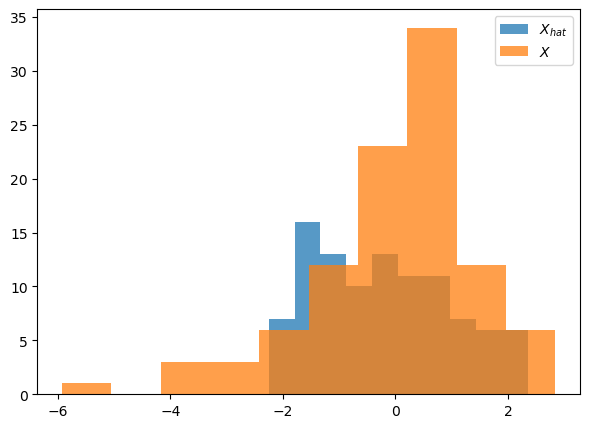

In [12]:
m = BernoulliNetwork(n=100, k=5, rho=0.5, copula_model='gaussian', marginals='t 5')
data = m.generate()
A = data['A']
B = data['B']
X = data['X']
Z = data['Z']

rng = np.random.default_rng(42)

X_model = FitIndependent(rng=rng, k=2, solver=MLE_logistic)
X_model.fit(data)
Z_model = FitIndependent(rng=rng, k=2, solver=MLE_logistic)
Z_model.fit(data)

Xhat = X_model.get_estimated()['estimated_latent'][0]
Zhat = Z_model.get_estimated()['estimated_latent'][0]

check_normality(Xhat[:, 0], "Xhat")
check_normality(X[:, 0], "X")

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.hist(Xhat[:, 0], alpha=0.75)
ax.hist(X[:, 0], alpha=0.75)
plt.legend(["$X_{hat}$", "$X$"])
plt.show()

--- Normality Report for: Xhat ---
Skewness: -0.0635 (Ideal: 0)
Excess Kurtosis: -0.8953 (Ideal: 0)
Shapiro-Wilk Test: p=0.0068 (Not Normal)
D'Agostino's K^2: p=0.0000 (Not Normal)
Anderson-Darling Stat: 1.0618
Anderson-Darling (5%): Not Normal

--- Normality Report for: X ---
Skewness: -0.0081 (Ideal: 0)
Excess Kurtosis: 0.0272 (Ideal: 0)
Shapiro-Wilk Test: p=0.9211 (Normal)
D'Agostino's K^2: p=0.9486 (Normal)
Anderson-Darling Stat: 0.2235
Anderson-Darling (5%): Normal



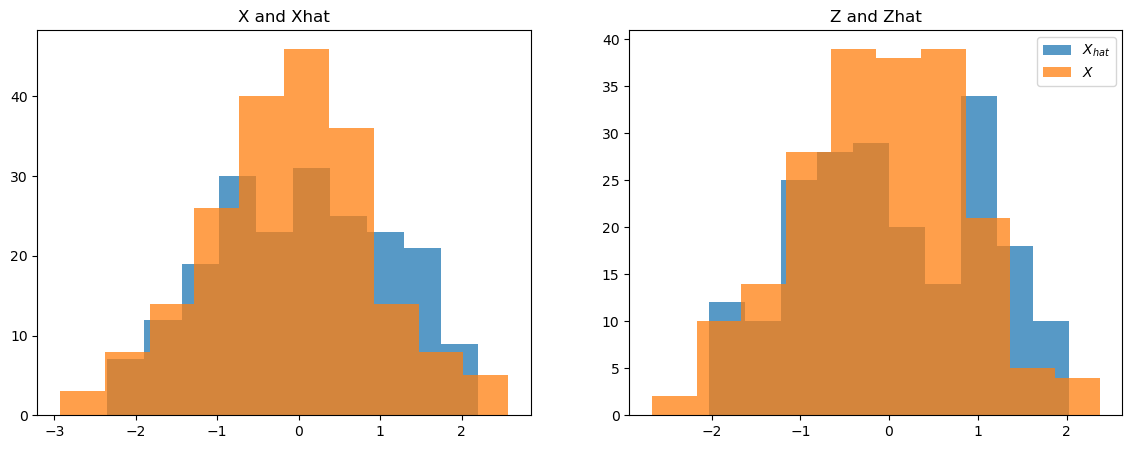

In [ ]:
m = GaussianNetwork(n=200, k=5, rho=0, copula_model='gaussian', marginals='gaussian')
data = m.generate()
A = data['A']
B = data['B']
X = data['X']
Z = data['Z']

rng = np.random.default_rng()

X_model = FitIndependent(rng=rng, k=2, solver=MLE_logistic)
X_model.fit(data)

Xhat = X_model.get_estimated()['estimated_latent'][0]
Zhat = X_model.get_estimated()['estimated_latent'][1]

check_normality(Xhat[:, 0], "Xhat")
check_normality(X[:, 0], "X")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(Xhat[:, 0], alpha=0.75)
ax[0].hist(X[:, 0], alpha=0.75)
ax[0].set_title("X and Xhat")
ax[1].hist(Zhat[:, 0], alpha=0.75)
ax[1].hist(Z[:, 0], alpha=0.75)
ax[1].set_title("Z and Zhat")
plt.legend(["$X_{hat}$", "$X$", "$Z_{hat}$", "$Z$"])
plt.show()